In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## Предобработка

Поля датасета: 

* is_pinned - Закреплен ли пост - (0, 1)
* comments - Словаь информации о комменатриях, содержащий информацию о возможности комментировать, смотреть и количество комментариев
* marked_as_ads - Отмечен ли пост как рекламный - (0, 1)
* attachments - Вложения в посте (фото, видео, ссылки) - список
* date - Дата публикации поста - таймстемп
* from_id - ID автора поста - int
* id_x - Уникальный идентификатор поста - int
* likes - Информация по лайкам поста (аналогично комментарием)
* reactions - Информация о всех реакциях поста (словарь или список)
* owner_id - ID владельца поста - дублирует from_id
* post_source - Источник поста (например, API, web, mobile) - словарь с полем type
* reposts - Количество репостов поста - словарь, где количество лежит в поле count
* text - Текст поста - str
* views - Количество просмотров поста - словарь, где количество лежит в поле count
* donut_miniapp_url - Ссылка на мини-приложение, если пост связан с VK Donut - str
* check_sign - наличие подписи - bool
* id_y - Дублирующий идентификатор, связанный с группой - int
* description - Описание сообщества, в котором опубликован пост - str
* members_count - Количество подписчиков в сообществе - int
* activity - Рубрика сообщества - str
* status - Статус сообщества - str
* site - Сайт сообщества - str
* name - Название сообщества - str
* screen_name - Короткое название сообщества (URL-адрес) - str
* verified - Проверено ли сообщество (есть ли галочка) - (0, 1)



In [155]:
df = pd.read_csv('../csv_files/df_wall.csv')
display(df.head())

,is_pinned,comments,marked_as_ads,attachments,date,from_id,id_x,likes,reactions,owner_id,...,check_sign,id_y,description,members_count,activity,status,site,name,screen_name,verified
0,1.0,"{'can_post': 1, 'can_view': 1, 'count': 74}",0,"[{'type': 'video', 'video': {'response_type': ...",1740042002,-211229778,49105,"{'can_like': 1, 'count': 3895, 'user_likes': 0...","[{'id': 0, 'title': 'Лайк', 'asset': {'animati...",211229778,...,NaN,211229778,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",NaN,https://www.youtube.com/channel/UCXDerjAwOSH30...,Женский Форум,zhenforum,1
1,NaN,"{'can_post': 1, 'can_view': 1, 'count': 2}",0,"[{'type': 'video', 'video': {'response_type': ...",1741093583,-211229778,49839,"{'can_like': 1, 'count': 1056, 'user_likes': 0...","{'count': 1056, 'items': [{'id': 0, 'count': 1...",211229778,...,NaN,211229778,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",NaN,https://www.youtube.com/channel/UCXDerjAwOSH30...,Женский Форум,zhenforum,1
2,NaN,"{'can_post': 1, 'can_view': 1, 'count': 6}",0,"[{'type': 'video', 'video': {'response_type': ...",1741007166,-211229778,49794,"{'can_like': 1, 'count': 1022, 'user_likes': 0...","{'count': 1022, 'items': [{'id': 0, 'count': 1...",211229778,...,NaN,211229778,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",NaN,https://www.youtube.com/channel/UCXDerjAwOSH30...,Женский Форум,zhenforum,1
3,NaN,"{'can_post': 1, 'can_view': 1, 'count': 7}",0,"[{'type': 'photo', 'photo': {'album_id': -7, '...",1740994531,-211229778,49786,"{'can_like': 1, 'count': 275, 'user_likes': 0,...","{'count': 275, 'items': [{'id': 0, 'count': 27...",211229778,...,NaN,211229778,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",NaN,https://www.youtube.com/channel/UCXDerjAwOSH30...,Женский Форум,zhenforum,1
4,NaN,"{'can_post': 1, 'can_view': 1, 'count': 39}",0,"[{'type': 'photo', 'photo': {'album_id': -7, '...",1740665284,-211229778,49617,"{'can_like': 1, 'count': 4967, 'user_likes': 0...","{'count': 4967, 'items': [{'id': 0, 'count': 4...",211229778,...,NaN,211229778,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",NaN,https://www.youtube.com/channel/UCXDerjAwOSH30...,Женский Форум,zhenforum,1


Размер полученного датасета

In [156]:
df.shape

(2626, 25)

Собрано 2626 постов, сейчас есть 25 полей, в которых содержится информация как о самом посте, так и сообществе, который опубликовал этот пост

По описанию полей видно, что много полей хранятся в неудобном виде. Приведем в порядок

None  в is_pinned по специфике сборки через АПИ означает, что пост не закреплен, поэтому заменим значения на 0

In [157]:
df['is_pinned'].fillna(0, inplace=True)
df['is_pinned'] = df['is_pinned'].astype(int)

/var/folders/wj/jzwd6lfn7xx02ns8v_wr29bm0000gn/T/ipykernel_97095/511727329.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





В поле о комментах записана инфа о возможности комментирования, просмотра поста и количества комментов. Выделим эту инфу в разные поля

In [158]:
df['can_comment'] = df['comments'].apply(lambda x: eval(x).get('can_post')) 
df['can_view'] = df['comments'].apply(lambda x: eval(x).get('can_view'))
df['comments_cnt'] = df['comments'].apply(lambda x: eval(x).get('count'))

В поле вложений лежит список всех вложений с кучей нформацией лишней, достанем только уникальные типы вложений поста

In [159]:
df['attachments_types'] = df['attachments'].apply(lambda x: set({item['type'] for item in eval(x)}))

Перевед дату в тип даты

In [160]:
df['date'] = pd.to_datetime(df['date'], unit='s')

По аналогии с комментариями раскрываем лайки

In [161]:
df['can_like'] = df['likes'].apply(lambda x: eval(x).get('can_like')) 
df['can_repost'] = df['likes'].apply(lambda x: int(not eval(x).get('repost_disabled')))
df['reactions_cnt'] = df['likes'].apply(lambda x: eval(x).get('count'))

Можно заметить, что поле с реакциями имеет разный формат, тут придется помучиться, чтобы хорошо преобразовать

In [162]:
reaction_titles = {
    0: 'Лайк',
    1: 'Смешно',
    2: 'Ого!',
    3: 'Восторг',
    4: 'Печаль',
    5: '&$#%!'
}

def parse_reactions(row):
    reactions = eval(row['reactions'])
    result = {}

    if isinstance(reactions, list):
        result['Лайк'] = row['reactions_cnt']

    elif isinstance(reactions, dict):
        items = reactions.get('items', [])
        for item in items:
            reaction_id = item.get('id')
            title = reaction_titles.get(reaction_id, 'Неизвестная реакция')
            count = item.get('count', 0)
            result[title] = count

    return result

df['reactions_types'] = df.apply(parse_reactions, axis=1)


Теперь сделаем имитацию OHE

In [163]:
for _, reaction  in reaction_titles.items():
    df[reaction] = df['reactions_types'].apply(lambda x: x.get(reaction, 0))

Далее приводятся в нормальный вид похожие по структуре поля (вытаскиваем колчиество или название)

In [164]:
df['source'] = df['post_source'].apply(lambda x: eval(x).get('type'))
df['reposts_cnt'] = df['reposts'].apply(lambda x: eval(x).get('count'))
df['views_cnt'] = df['views'].apply(lambda x: eval(x).get('count'))

donut_miniapp_url - сама ссылка нам не нужна, но будем хранить информацию о том, пользуется ли сообщество такой штукой

In [165]:
df['is_donut'] = df['donut_miniapp_url'].apply(lambda x: 0 if pd.isna(x) else 1)

Что-то похожее с check_sign

In [166]:
df['is_sign'] = df['check_sign'].apply(lambda x: 0 if pd.isna(x) else 1)

Статус сообщества, Сайт сообщества сами не нужны, а вот с информацией есть ли они было бы интересно ознакомиться

In [167]:
df['is_status'] = df['status'].apply(lambda x: 0 if pd.isna(x) else 1)
df['is_site'] = df['site'].apply(lambda x: 0 if pd.isna(x) else 1)

Удаляем айдишники, так как для анализа они не нужны, а имена сообществ у нас уникальные сами по себе, также удалим короткое название сообщества и поля, которые мы преобразовали

In [168]:
df.drop(columns=['comments' , 'attachments'      , 'from_id', 'id_x'      , 'owner_id'   , 
                 'id_y'     , 'screen_name'      , 'likes'  , 'check_sign', 'post_source',
                 'reactions', 'reactions_types'  , 'reposts', 'views'     ,  
                 'status'   , 'donut_miniapp_url', 'site'   ,], inplace=True)

In [169]:
df.head()

,is_pinned,marked_as_ads,date,text,description,members_count,activity,name,verified,can_comment,...,Восторг,Печаль,&$#%!,source,reposts_cnt,views_cnt,is_donut,is_sign,is_status,is_site
0,1,0,2025-02-20 09:00:02,Можно бесконечно смотреть на три явления: как ...,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,0,0,vk,2708,727617,0,0,0,1
1,0,0,2025-03-04 13:06:23,NaN,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,0,0,vk,87,99412,0,0,0,1
2,0,0,2025-03-03 13:06:06,NaN,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,0,0,vk,40,95628,0,0,0,1
3,0,0,2025-03-03 09:35:31,Сегодня в 15:00 (мск) откроем продажу билетов ...,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,1,0,0,api,13,105038,0,0,0,1
4,0,0,2025-02-27 14:08:04,✍ Ты медленно пишешь заявление на увольнение...,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,0,1,api,1083,560361,0,0,0,1


Итого с пустыми значениями остались описание сообщества и текст, так как это строки, то сюда можно подставить пустую строку - то есть в описании или посте пусто, нет нарушений

In [170]:
df.isnull().sum()


is_pinned              0
marked_as_ads          0
date                   0
text                 790
description          101
members_count          0
activity               0
name                   0
verified               0
can_comment            0
can_view               0
comments_cnt           0
attachments_types      0
can_like               0
can_repost             0
reactions_cnt          0
Лайк                   0
Смешно                 0
Ого!                   0
Восторг                0
Печаль                 0
&$#%!                  0
source                 0
reposts_cnt            0
views_cnt              0
is_donut               0
is_sign                0
is_status              0
is_site                0
dtype: int64

In [171]:
df['text'].fillna("", inplace=True)
df['description'].fillna("", inplace=True)

/var/folders/wj/jzwd6lfn7xx02ns8v_wr29bm0000gn/T/ipykernel_97095/2947034952.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/var/folders/wj/jzwd6lfn7xx02ns8v_wr29bm0000gn/T/ipykernel_97095/2947034952.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [172]:
df.isnull().sum()

is_pinned            0
marked_as_ads        0
date                 0
text                 0
description          0
members_count        0
activity             0
name                 0
verified             0
can_comment          0
can_view             0
comments_cnt         0
attachments_types    0
can_like             0
can_repost           0
reactions_cnt        0
Лайк                 0
Смешно               0
Ого!                 0
Восторг              0
Печаль               0
&$#%!                0
source               0
reposts_cnt          0
views_cnt            0
is_donut             0
is_sign              0
is_status            0
is_site              0
dtype: int64

Ура!)

## Анализ

### Текст

Анализ длины текстов к постам

In [177]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

fig = px.histogram(df, x="text_length", nbins=100)
fig.show()

В основном посты имеют небольшие тексты (до 250 слов) - ненагромажденные тексты без воды, хотя те, что ближе к 250 уже как сочинение в школе, но есть прям сильные выбросы с огромными текстами, давайте посомтрим на них

In [178]:
df[df['text_length'] > 250]

,is_pinned,marked_as_ads,date,text,description,members_count,activity,name,verified,can_comment,...,Печаль,&$#%!,source,reposts_cnt,views_cnt,is_donut,is_sign,is_status,is_site,text_length
715,0,0,2025-03-03 08:00:57,Ответственное потребление \n \nВот в моем детс...,💰 Любая хуйня за ваши деньги в рубрике #нативн...,1374373,Дом культуры,Артемий Лебедев,1,1,...,0,0,api,86,161137,1,0,1,1,268
728,0,0,2025-02-26 16:25:29,Цифрубль \n \nПрошу минуточку внимания. У нас ...,💰 Любая хуйня за ваши деньги в рубрике #нативн...,1374373,Дом культуры,Артемий Лебедев,1,1,...,1,1,api,254,182652,1,0,1,1,290
1788,0,0,2024-12-31 17:22:06,"2024-ый, для HARDCORE, стал годом развития Рос...",Официальный паблик HARDCORE MEDIA – одного из ...,874420,Спортивная организация,Hardcore Fighting Championship,0,1,...,0,0,api,9,186526,0,0,1,1,307
1824,0,0,2025-02-20 08:00:00,Книжная полка \n \nОчень долго не доходили рук...,"Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,0,0,api,1377,133422,0,0,1,1,487
1827,0,0,2025-02-13 08:00:00,"Почему именно сейчас? \n \nКороч, на днях зави...","Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,0,0,api,45,45770,0,0,1,1,1313
1830,0,0,2025-02-07 08:05:00,Мысли о свеженькой блокировке любимого Ютуба. ...,"Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,0,0,api,86,108303,0,0,1,1,685
1831,0,0,2025-02-07 08:00:00,Мысли о свеженькой блокировке любимого Ютуба. ...,"Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,0,1,api,38,32784,0,0,1,1,2049
1832,0,0,2025-01-31 08:00:00,"Рубрика «Горит жопа, ничего не могу с собой по...","Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,3,0,api,179,181036,0,0,1,1,278
1834,0,0,2025-01-23 08:00:00,"Итак, есть чем с вами поделиться. \n \nЯ приме...","Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,2,1,api,101,131285,0,0,1,1,370
1836,0,0,2025-01-17 08:00:00,"Замедление Ютуба \n \nИтак, хочется поделиться...","Ссылки не в Сибири, а в описании!\nПо любым во...",339842,Блогер,Асафьев Стас,1,1,...,2,1,api,303,143198,0,0,1,1,1233


Видим, что большие тексты это в основном посты-статьи или посты блогеров, подводящие какие-то итоги значимого события 

In [179]:
df[df['text_length'] > 250].groupby('name').size().reset_index().sort_values(0, ascending=False)

,name,0
2,Асафьев Стас,14
1,Артемий Лебедев,2
0,Hardcore Fighting Championship,1


Больше всех длинные посты пишет Асафьев Стас (автоблогер) - пишет какие-то статьи о машинах и прогнозах и иногда Артемий Лебедев (дизайнер)

In [180]:
fig_views = px.scatter(df, x="text_length", y="views_cnt",
                       trendline="ols",
                       labels={"text_length": "Длина текста", "views_cnt": "Количество просмотров"},
                       title="Зависимость количества просмотров от длины текста")
fig_views.show()

fig_reposts = px.scatter(df, x="text_length", y="reposts_cnt",
                         trendline="ols",
                         labels={"text_length": "Длина текста", "reposts_cnt": "Количество репостов"},
                         title="Зависимость количества репостов от длины текста")
fig_reposts.show()

fig_reactions = px.scatter(df, x="text_length", y="reactions_cnt",
                           trendline="ols",
                           labels={"text_length": "Длина текста", "reactions_cnt": "Количество реакций"},
                           title="Зависимость количества реакций от длины текста")
fig_reactions.show()

Видим прямую зависимость количества просмотров от длины текста - для меня это удивительно, я думала, что чем длинне текст, тем вероятнее его не будут читать
Также прямая зависимость длины и репостов, но там близко к константе
А вот в реакциях видим четкую обратную связь, гипотеза, что длинные тексты именно читают, а не лайкают и быстро пролистывают

Посомтрим как часто используют смайлики

In [181]:
def count_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F" 
        "\U0001F300-\U0001F5FF"  
        "\U0001F680-\U0001F6FF" 
        "\U0001F1E0-\U0001F1FF"  
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return len(emoji_pattern.findall(text))

df['emoji_count'] = df['text'].apply(count_emojis)
df.head()

,is_pinned,marked_as_ads,date,text,description,members_count,activity,name,verified,can_comment,...,&$#%!,source,reposts_cnt,views_cnt,is_donut,is_sign,is_status,is_site,text_length,emoji_count
0,1,0,2025-02-20 09:00:02,Можно бесконечно смотреть на три явления: как ...,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,vk,2708,727617,0,0,0,1,32,3
1,0,0,2025-03-04 13:06:23,,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,vk,87,99412,0,0,0,1,0,0
2,0,0,2025-03-03 13:06:06,,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,vk,40,95628,0,0,0,1,0,0
3,0,0,2025-03-03 09:35:31,Сегодня в 15:00 (мск) откроем продажу билетов ...,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,0,api,13,105038,0,0,0,1,24,0
4,0,0,2025-02-27 14:08:04,✍ Ты медленно пишешь заявление на увольнение...,"Шоу, в котором четыре девушки дают советы по л...",706762,"Шоу, передача",Женский Форум,1,1,...,1,api,1083,560361,0,0,0,1,7,1


In [182]:
fig = px.histogram(df, x="emoji_count")
fig.show()

Довольно мало постов использует смайлики, хотя как мне кажется они привлекают внимание

In [183]:
fig_views = px.scatter(df, x="emoji_count", y="views_cnt",
                       trendline="ols",
                       labels={"emoji_count": "Количество смайликов", "views_cnt": "Количество просмотров"},
                       title="Зависимость количества просмотров от количества смайликов")
fig_views.show()

fig_reposts = px.scatter(df, x="emoji_count", y="reposts_cnt",
                         trendline="ols",
                         labels={"emoji_count": "Количество смайликов", "reposts_cnt": "Количество репостов"},
                         title="Зависимость количества репостов от количества смайликов")
fig_reposts.show()

fig_reactions = px.scatter(df, x="emoji_count", y="reactions_cnt",
                           trendline="ols",
                           labels={"emoji_count": "Количество смайликов", "reactions_cnt": "Количество реакций"},
                           title="Зависимость количества реакций от количества смайликова")
fig_reactions.show()

Видим, что просмотров имеет прямую связь с колчиством смаликов, позед посомтрим на кожффициент корреляции, потому что кажется что связь слабая

In [184]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aazaides/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/aazaides/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/aazaides/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [187]:
def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

df['clean_text'] = df['text'].apply(remove_urls)

df['clean_text'] = df['clean_text'].str.lower()

df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

df['tokens'] = df['clean_text'].apply(lambda x: nltk.word_tokenize(x))

stop_words_ru = set(stopwords.words('russian'))
stop_words_en = set(stopwords.words('english'))
all_stop_words = stop_words_ru.union(stop_words_en)

df['tokens'] = df['tokens'].apply(lambda x: token for token in x if token not in all_stop_words )

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(lambda x: lemmatizer.lemmatize(token) for token in x)

all_words_lemmatized = []
for tokens in df['tokens']:
    all_words_lemmatized.extend(tokens)

word_counts_lemmatized = Counter(all_words_lemmatized)
most_common_words_lemmatized = word_counts_lemmatized.most_common(10)
print("Топ-10 самых часто встречающихся слов после лемматизации:")
print(most_common_words_lemmatized)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/Users/aazaides/nltk_data'
    - '/opt/homebrew/opt/python@3.13/Frameworks/Python.framework/Versions/3.13/nltk_data'
    - '/opt/homebrew/opt/python@3.13/Frameworks/Python.framework/Versions/3.13/share/nltk_data'
    - '/opt/homebrew/opt/python@3.13/Frameworks/Python.framework/Versions/3.13/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


### Аудитория

In [200]:
df['has_text'] = df['text_length'].apply(lambda x: x > 0)

df_text = df.groupby('has_text', as_index=False)[['reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']].mean()

fig = go.Figure()

metrics = ['reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']
for metric in metrics:
    fig.add_trace(go.Bar(
        x=df_text['has_text'].map({True: 'С текстом', False: 'Без текста'}),
        y=df_text[metric],
        name=metric.split('_')[0]
    ))

fig.update_layout(
    title='Средняя вовлеченность для постов с текстом и без текста',
    barmode='group',
    xaxis_title='Наличие текста',
    yaxis_title='Средние показатели'
)
fig.show()

Смотрят и комментя больше посты с текстом, наверное очевидно, так как там есть что сомтреть. Если текста нет, значит там фотка или видео, которые люди могут сомтреть в дургих местах. Реакции и репосты визуально не стат значимо отличаются

In [205]:
df_name = df.groupby('name', as_index=False)[['members_count', 'reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']].mean()

fig_reactions = px.scatter(df_name, x='members_count', y='reactions_cnt', 
                  size='views_cnt', hover_name='name',
                  title='Корреляция количества подписчиков и популярных постов')
fig_reactions.update_xaxes(title='Среднее число подписчиков')
fig_reactions.update_yaxes(title='Среднее число лайков')
fig_reactions.show()

fig_comments = px.scatter(df_name, x='members_count', y='comments_cnt', 
                  size='views_cnt', hover_name='name')
fig_comments.update_xaxes(title='Среднее число подписчиков')
fig_comments.update_yaxes(title='Среднее число комментов')
fig_comments.show()

fig_views = px.scatter(df_name, x='members_count', y='reposts_cnt', 
                  size='views_cnt', hover_name='name')
fig_views.update_xaxes(title='Среднее число подписчиков')
fig_views.update_yaxes(title='Среднее число прросмотров')
fig_views.show()

Видим выбросы в виде А4 и ГАЗ, а также видим, что есть кружочки одиннакого размера - то есть похожее количество подписчиков, при этом количество лайков сильно отличается

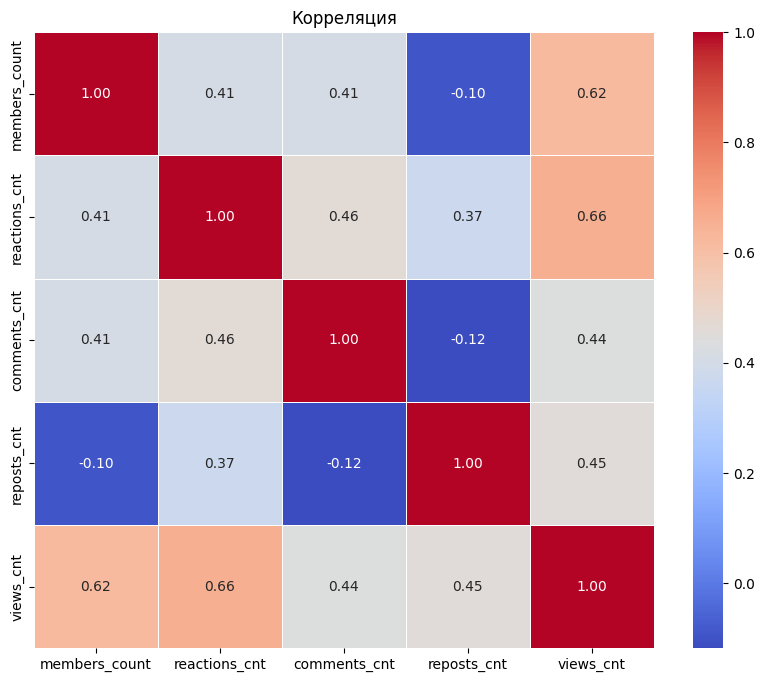

In [212]:
corr = df_name[['members_count', 'reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляция')
plt.show()

In [210]:
df_pinned = df.groupby('is_pinned', as_index=False)[['reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']].mean()

fig = go.Figure()
metrics = ['reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']
for metric in metrics:
    fig.add_trace(go.Bar(
        x=df_pinned['is_pinned'].map({1:'Закреплены', 0:'Не закреплены'}),
        y=df_pinned[metric],
        name=metric.split('_')[0]
    ))

fig.update_layout(title='Сравнение вовлеченности закрепленных и обычных постов',
                   barmode='group',
                   xaxis_title='Тип поста',
                   yaxis_title='Средние показатели'
                  )
fig.show()

In [220]:
df['has_video'] = df['attachments_types'].apply(lambda x: 'video' in x)

df_video = df.groupby('has_video', as_index=False)[['reactions_cnt', 'comments_cnt', 'reposts_cnt', 'views_cnt']].mean()

fig = go.Figure()
for metric in metrics:
    fig.add_trace(go.Bar(
        x=df_video['has_video'].map({True:'С видео', False:'Без видео'}),
        y=df_video[metric],
        name=metric.split('_')[0]
    ))

fig.update_layout(title='Средняя вовлеченность для постов с видео и без видео',
                   barmode='group',
                   xaxis_title='Наличие видео',
                   yaxis_title='Средние показатели'
                )
fig.show()